In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import KFold


In [2]:
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 2.1.3


In [3]:
df = pd.read_csv('Food_Time_Data_Set.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,temperature,humidity,precipitation,weather_description,Unnamed: 14,Traffic_Level,Distance (km),TARGET
0,4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,17.11,77.0,0.0,haze,NaN,Low,NaN,21.66666667
1,B379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,19.50,93.0,0.0,mist,NaN,Very High,37.17,85.26666667
2,5D6D,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,20.45,91.0,0.0,mist,NaN,Low,3.34,28.58333333
3,7A6A,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,23.86,78.0,0.0,mist,NaN,Moderate,10.05,35.18333333
4,70A2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,26.55,87.0,0.0,mist,NaN,High,9.89,43.45


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10000 non-null  object 
 1   Delivery_person_ID           10000 non-null  object 
 2   Delivery_person_Age          10000 non-null  float64
 3   Delivery_person_Ratings      10000 non-null  float64
 4   Restaurant_latitude          10000 non-null  float64
 5   Restaurant_longitude         10000 non-null  float64
 6   Delivery_location_latitude   10000 non-null  float64
 7   Delivery_location_longitude  10000 non-null  float64
 8   Type_of_order                10000 non-null  object 
 9   Type_of_vehicle              10000 non-null  object 
 10  temperature                  9995 non-null   float64
 11  humidity                     9995 non-null   float64
 12  precipitation                9995 non-null   float64
 13  weather_descript

### Step 1: Prepare the data

In [5]:
# Drop unnecessary columns
df.drop(columns=['Unnamed: 14'], inplace=True)

# Drop rows where TARGET contains null values
df.dropna(subset=['TARGET'], inplace=True)

# Drop rows where TARGET contains '#VALUE!'
df = df[df['TARGET'] != '#VALUE!']

# Convert TARGET to float and round to 1 decimal place
df['TARGET'] = pd.to_numeric(df['TARGET'], errors='coerce')  # Convert to numeric, invalid values become NaN
df['TARGET'] = df['TARGET'].round(1)  # Round to 1 decimal place

# Remove any NaN values that might have been created during conversion
df.dropna(subset=['TARGET'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9040 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           9040 non-null   object 
 1   Delivery_person_ID           9040 non-null   object 
 2   Delivery_person_Age          9040 non-null   float64
 3   Delivery_person_Ratings      9040 non-null   float64
 4   Restaurant_latitude          9040 non-null   float64
 5   Restaurant_longitude         9040 non-null   float64
 6   Delivery_location_latitude   9040 non-null   float64
 7   Delivery_location_longitude  9040 non-null   float64
 8   Type_of_order                9040 non-null   object 
 9   Type_of_vehicle              9040 non-null   object 
 10  temperature                  9040 non-null   float64
 11  humidity                     9040 non-null   float64
 12  precipitation                9040 non-null   float64
 13  weather_description    

In [7]:
# Handle missing values in Distance
df['Distance (km)'] = df['Distance (km)'].fillna(df['Distance (km)'].mean())
df['Distance (km)'] = df['Distance (km)'].round(1)

In [8]:
# Drop ID columns as they don't contribute to prediction
df = df.drop(['ID', 'Delivery_person_ID'], axis=1)

# Clean and encode categorical variables
categorical_columns = ['Type_of_order', 'Type_of_vehicle', 'weather_description', 'Traffic_Level']
encoders = {}

# Fix categorical columns labels
for col in categorical_columns:
    df[col] = df[col].str.strip().str.title()  # Removes leading and trailing whitespace then capitalizes first letter of each word


# Then perform encoding
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [9]:
# For each categorical column, show the encoding mapping
for col, encoder in encoders.items():
    print(f"\nEncodings for {col}:")
    # Create a dictionary mapping classes to their encoded values
    mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    for category, encoded_value in mapping.items():
        print(f"  {category}: {encoded_value}")


Encodings for Type_of_order:
  Buffet: 0
  Drinks: 1
  Meal: 2
  Snack: 3

Encodings for Type_of_vehicle:
  Bicycle: 0
  Electric_Scooter: 1
  Motorcycle: 2
  Scooter: 3

Encodings for weather_description:
  Broken Clouds: 0
  Clear Sky: 1
  Few Clouds: 2
  Fog: 3
  Haze: 4
  Mist: 5
  Moderate Rain: 6
  Overcast Clouds: 7
  Scattered Clouds: 8
  Smoke: 9

Encodings for Traffic_Level:
  High: 0
  Low: 1
  Moderate: 2
  Very High: 3
  Very Low: 4


### Step 2: Split features and target

In [10]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

This approach will ensure that you now have:
- X_train, y_train (80% of the data) for training,
- X_test, y_test (10% of the data) for test evaluation/validation,
- X_final_test, y_final_test (10% of the data) for final testing (unseen data).

In [11]:
# Split data into training 80% and testing 20% sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

# Further split the 20% test set into two 10% sets (test evaluation/validation and final test)
X_test, X_final_test, y_test, y_final_test = train_test_split(X_test, y_test, test_size=0.5, random_state=13)

### Step 3: Train the XGBoost model (manual)

In [12]:
# Convert data into DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [13]:
# Set parameters
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.01,
    "max_depth": 4,
    "eval_metric": "rmse",
    "random_state": 13,
}

In [14]:
# Set evaluation list
evallist = [(dtrain, 'train'), (dtest, 'test')]

# Dictionary to store evaluation results
evals_result = {}

# Train model
num_round = 100

xgb_model = xgb.train(
    params,
    dtrain,
    num_round,
    evallist,
    evals_result=evals_result,
    verbose_eval=10
)

[0]	train-rmse:16.41042	test-rmse:16.69009
[10]	train-rmse:15.07763	test-rmse:15.33817
[20]	train-rmse:13.88820	test-rmse:14.12757
[30]	train-rmse:12.82711	test-rmse:13.04490
[40]	train-rmse:11.88364	test-rmse:12.07981
[50]	train-rmse:11.04753	test-rmse:11.22011
[60]	train-rmse:10.30117	test-rmse:10.45677
[70]	train-rmse:9.63887	test-rmse:9.77813
[80]	train-rmse:9.05274	test-rmse:9.17394
[90]	train-rmse:8.53705	test-rmse:8.64612
[99]	train-rmse:8.11845	test-rmse:8.21997


/opt/anaconda3/envs/mis636-pybiz/lib/python3.12/site-packages/xgboost/core.py:723: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


### Step 4: Evaluate the model (manual)

In [15]:
# Make predictions
dtest = xgb.DMatrix(X_test)

y_pred = xgb_model.predict(dtest)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"- RMSE: {rmse:.4f}")
print(f"- MAE: {mae:.4f}")
print(f"- R²: {r2:.4f}")




Model Evaluation Metrics:
- RMSE: 8.2200
- MAE: 6.1583
- R²: 0.7608


### Step 5: Plot learning curves (manual)

Plot training test deviance for manual model

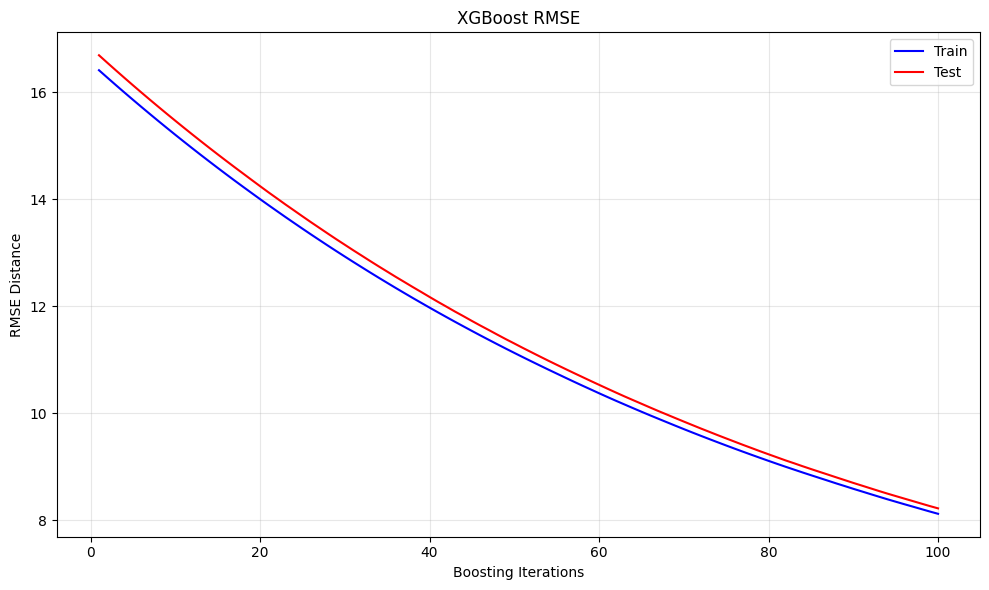

In [16]:
# Get the RMSE values for training and testing
train_rmse = evals_result['train']['rmse']
test_rmse = evals_result['test']['rmse']

# Create sequence of epochs
epochs = range(1, len(train_rmse) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_rmse, 'b-', label='Train')
plt.plot(epochs, test_rmse, 'r-', label='Test')

# Customize the plot
plt.title('XGBoost RMSE')
plt.xlabel('Boosting Iterations')
plt.ylabel('RMSE Distance')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

Visualize tree for manual model

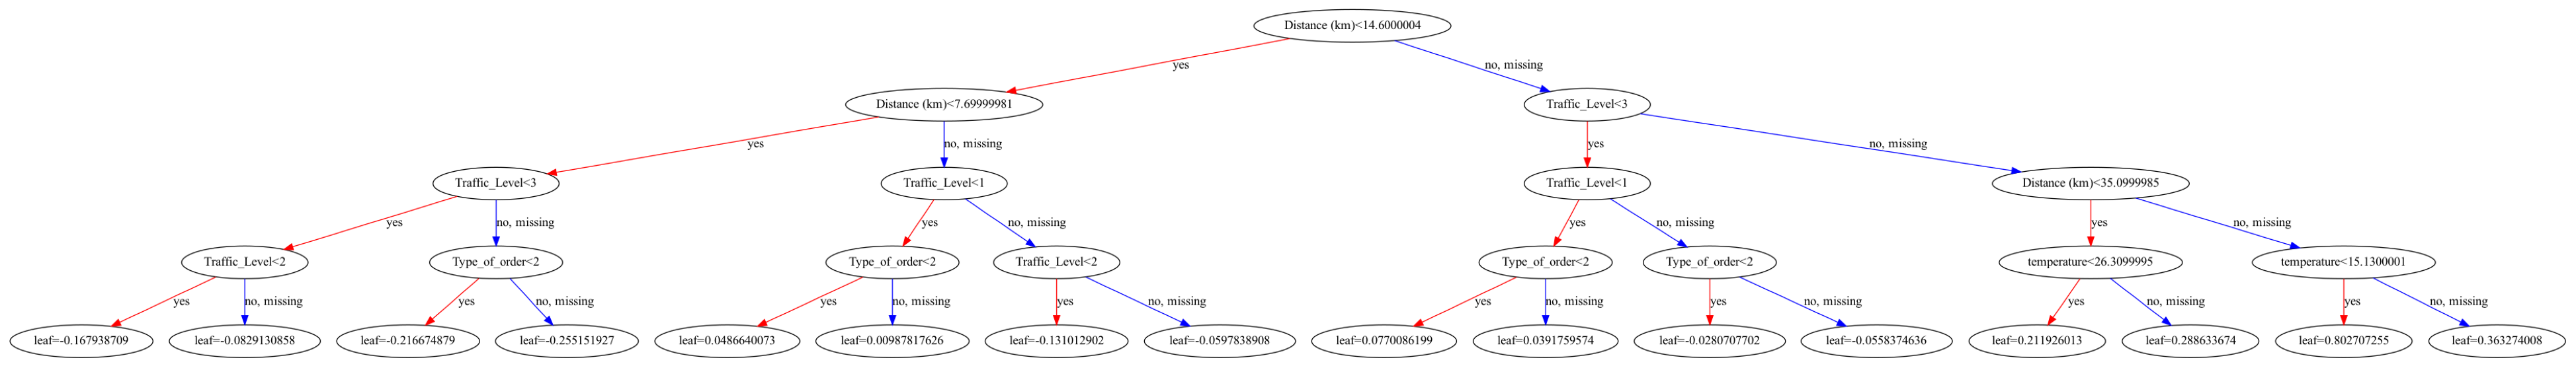

In [17]:
plt.rcParams['figure.figsize'] = (50, 25)
xgb.plot_tree(xgb_model, num_trees=0)
plt.show()


### Step 6: Feature importance

Importance is calculated with either “gain”, “weight”, or “cover”

- ”gain” is the average gain of splits which use the feature
- ”weight” is the number of times a feature appears in a tree
- ”cover” is the average coverage of splits which use the feature (where coverage is defined as the number of samples affected by the split)



In [18]:
# Gain
importance_scores = xgb_model.get_score(importance_type='gain')

# Sort features by importance score
sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

# Print feature importance
print("\nFeature Importance, Gain (High to Low):")
for feature, score in sorted_features:
    print(f"- {feature}: {score:.2f}")


Feature Importance, Gain (High to Low):
- Distance (km): 148643.80
- Traffic_Level: 36598.07
- Delivery_location_longitude: 18361.04
- temperature: 13646.13
- Delivery_location_latitude: 8627.23
- Restaurant_latitude: 6612.79
- humidity: 3505.90
- weather_description: 2301.60
- Type_of_order: 1877.91


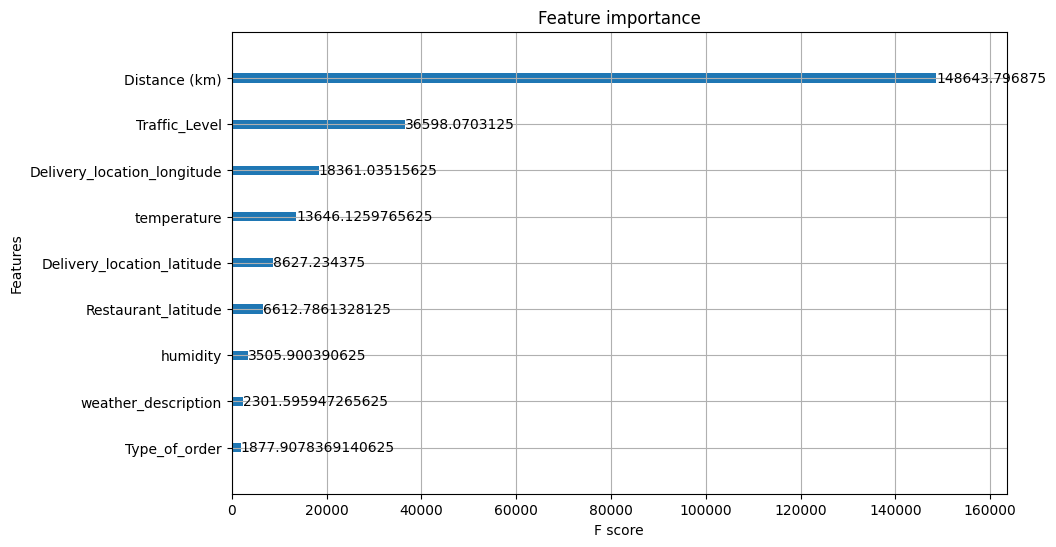

In [19]:
plt.rcParams['figure.figsize'] = (10, 6)
xgb.plot_importance(xgb_model, importance_type='gain')
plt.show()

Cleaning up the above plot

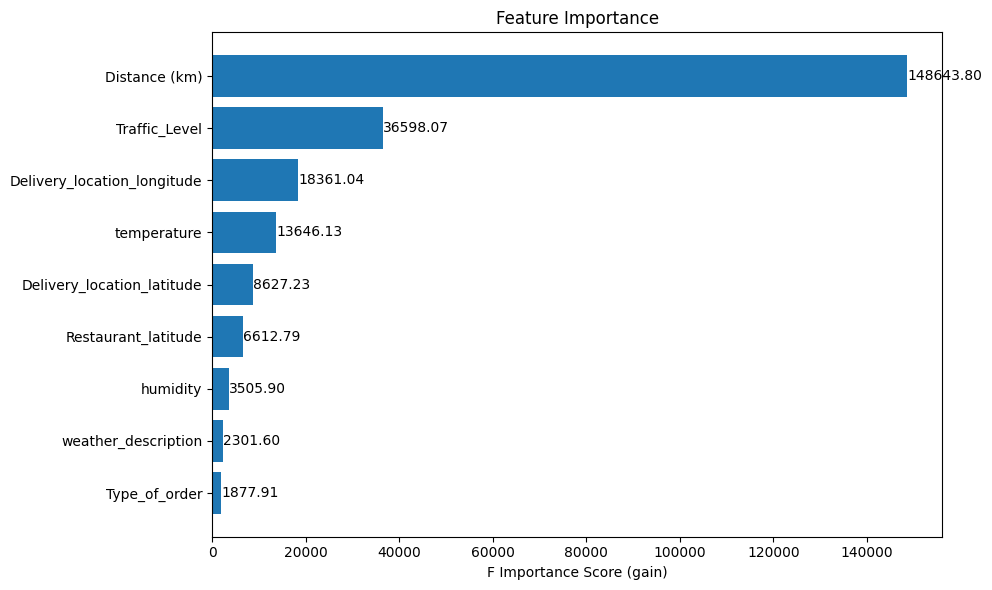

In [20]:
# Get feature importance scores - Gain
importance_scores = xgb_model.get_score(importance_type='gain')

# Convert to list of tuples and sort by importance
importance_tuples = [(k, v) for k, v in importance_scores.items()]
importance_tuples.sort(key=lambda x: x[1])

# Separate features and scores
features = [tup[0] for tup in importance_tuples]
scores = [tup[1] for tup in importance_tuples]

# Create plot
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(scores)), scores)

# Add formatted labels
for rect in bars:
    width = rect.get_width()
    plt.text(width, rect.get_y() + rect.get_height()/2, 
             f'{width:.2f}', 
             ha='left', va='center',
             fontsize=10)

# Customize plot
plt.yticks(range(len(features)), features)
plt.xlabel('F Importance Score (gain)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [21]:
# Weight
importance_scores = xgb_model.get_score(importance_type='weight')

# Sort features by importance score
sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

# Print feature importance
print("\nFeature Importance, Weight (High to Low):")
for feature, score in sorted_features:
    print(f"- {feature}: {score:.2f}")


Feature Importance, Weight (High to Low):
- Traffic_Level: 489.00
- Distance (km): 365.00
- Type_of_order: 325.00
- temperature: 161.00
- humidity: 63.00
- weather_description: 62.00
- Delivery_location_latitude: 18.00
- Restaurant_latitude: 15.00
- Delivery_location_longitude: 2.00


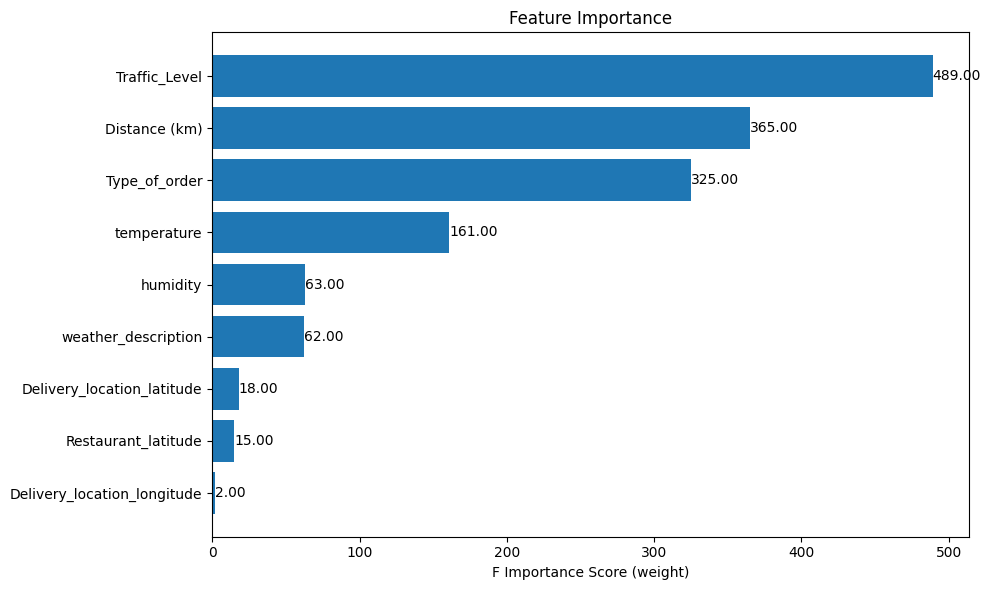

In [22]:
# Get feature importance scores - Weight
importance_scores = xgb_model.get_score(importance_type='weight')

# Convert to list of tuples and sort by importance
importance_tuples = [(k, v) for k, v in importance_scores.items()]
importance_tuples.sort(key=lambda x: x[1])

# Separate features and scores
features = [tup[0] for tup in importance_tuples]
scores = [tup[1] for tup in importance_tuples]

# Create plot
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(scores)), scores)

# Add formatted labels
for rect in bars:
    width = rect.get_width()
    plt.text(width, rect.get_y() + rect.get_height()/2, 
             f'{width:.2f}', 
             ha='left', va='center',
             fontsize=10)

# Customize plot
plt.yticks(range(len(features)), features)
plt.xlabel('F Importance Score (weight)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [23]:
# Cover
importance_scores = xgb_model.get_score(importance_type='cover')

# Sort features by importance score
sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

# Print feature importance
print("\nFeature Importance, Cover (High to Low):")
for feature, score in sorted_features:
    print(f"- {feature}: {score:.2f}")


Feature Importance, Cover (High to Low):
- Distance (km): 3795.95
- Traffic_Level: 2020.65
- weather_description: 961.13
- temperature: 836.50
- Type_of_order: 820.39
- humidity: 787.52
- Restaurant_latitude: 517.67
- Delivery_location_longitude: 48.00
- Delivery_location_latitude: 45.06


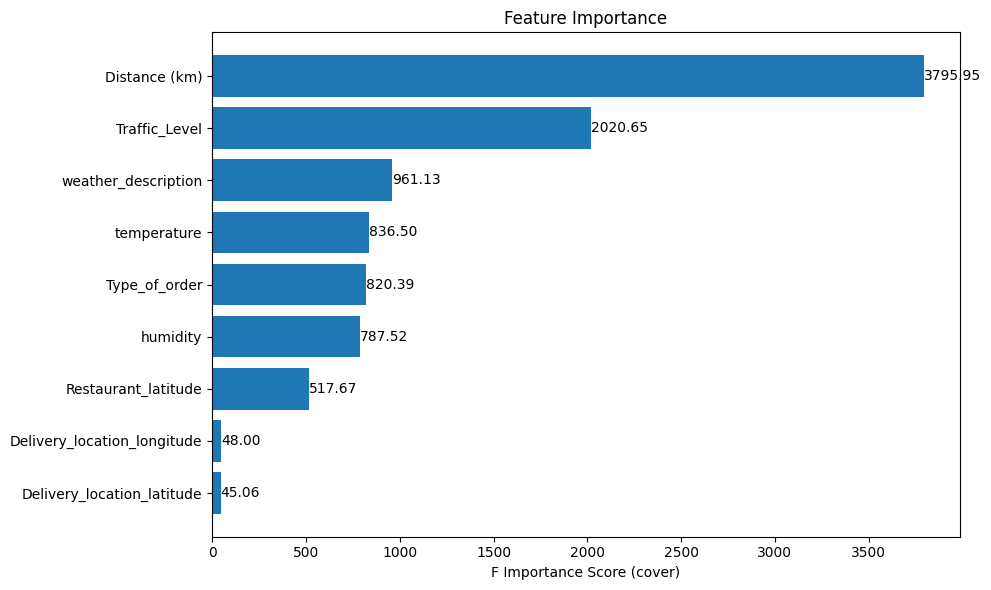

In [24]:
# Get feature importance scores - Cover
importance_scores = xgb_model.get_score(importance_type='cover')

# Convert to list of tuples and sort by importance
importance_tuples = [(k, v) for k, v in importance_scores.items()]
importance_tuples.sort(key=lambda x: x[1])

# Separate features and scores
features = [tup[0] for tup in importance_tuples]
scores = [tup[1] for tup in importance_tuples]

# Create plot
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(scores)), scores)

# Add formatted labels
for rect in bars:
    width = rect.get_width()
    plt.text(width, rect.get_y() + rect.get_height()/2, 
             f'{width:.2f}', 
             ha='left', va='center',
             fontsize=10)

# Customize plot
plt.yticks(range(len(features)), features)
plt.xlabel('F Importance Score (cover)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

### Step 7: Cross validation and Hyperparameter tuning

In [25]:
def manual_cross_val_score(params, X, y, n_folds=5):
    """
    Perform manual cross-validation for XGBoost
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=13)
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Convert to DMatrix
        dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
        dval = xgb.DMatrix(X_val_fold, label=y_val_fold)
        
        # Train model
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=100,
            evals=[(dval, 'val')],
            verbose_eval=False
        )
        
        # Make predictions
        y_pred = model.predict(dval)
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
        scores.append(rmse)
    
    return np.mean(scores), np.std(scores)

def tune_xgboost_manual(X_train, y_train):
    """
    Manual parameter tuning for XGBoost
    """
    # Base parameters
    base_params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 13
    }
    
    # Parameter grid
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 0.9, 1.0],
    }
    
    # Store results
    results = []
    
    # Generate all parameter combinations
    param_combinations = [dict(zip(param_grid.keys(), v)) 
                        for v in product(*param_grid.values())]
    
    print(f"Testing {len(param_combinations)} parameter combinations...")
    
    for params in param_combinations:
        # Combine with base parameters
        current_params = {**base_params, **params}
        
        # Perform cross-validation
        mean_rmse, std_rmse = manual_cross_val_score(current_params, X_train, y_train)
        
        results.append({
            'params': params,
            'mean_rmse': mean_rmse,
            'std_rmse': std_rmse
        })
        
        print(f"Parameters: {params}")
        print(f"RMSE: {mean_rmse:.4f} (+/- {std_rmse:.4f})")
        print("-" * 50)
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best parameters
    best_idx = results_df['mean_rmse'].argmin()
    best_params = results_df.iloc[best_idx]['params']
    
    print("\n***** Best parameters found: *****")
    print(best_params)
    print(f"***** Best RMSE: {results_df.iloc[best_idx]['mean_rmse']:.4f} *****")
    
    # Train final model with best parameters
    best_params = {**base_params, **best_params}
    dtrain = xgb.DMatrix(X_train, label=y_train)
    final_model = xgb.train(best_params, dtrain, num_boost_round=100)
    
    # Plot parameter effects
    plot_parameter_effects(results_df)

    # Before returning, create the complete parameter dictionary
    best_params_complete = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 13,
        'max_depth': best_params['max_depth'],
        'learning_rate': best_params['learning_rate'],
        'min_child_weight': best_params['min_child_weight'],
        'subsample': best_params['subsample']
    }

    return final_model, results_df, best_params_complete

def plot_parameter_effects(results_df):
    """
    Plot the effects of different parameters on model performance
    """
    params = results_df['params'].iloc[0].keys()
    n_params = len(params)
    fig, axes = plt.subplots((n_params + 1) // 2, 2, figsize=(15, 5 * ((n_params + 1) // 2)))
    axes = axes.ravel()
    
    for idx, param in enumerate(params):
        # Extract values and scores for this parameter
        param_values = [p[param] for p in results_df['params']]
        
        # Calculate mean RMSE for each parameter value
        unique_values = sorted(set(param_values))
        mean_rmses = []
        
        for value in unique_values:
            mask = [p[param] == value for p in results_df['params']]
            mean_rmse = results_df.loc[mask, 'mean_rmse'].mean()
            mean_rmses.append(mean_rmse)
        
        # Plot
        axes[idx].plot(unique_values, mean_rmses, 'o-')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel('Mean RMSE')
        axes[idx].set_title(f'Effect of {param}')
        axes[idx].grid(True)
    
    # Remove empty subplots
    for idx in range(n_params, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

def evaluate_xgboost_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate XGBoost model performance
    """
    
    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    # Make predictions
    y_train_pred = model.predict(dtrain)
    y_test_pred = model.predict(dtest)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print("\nModel Performance Metrics:")
    print(f"- Training RMSE: {train_rmse:.4f}")
    print(f"- Testing RMSE: {test_rmse:.4f}")

    print(f"- Training MAE: {train_mae:.4f}")
    print(f"- Testing MAE: {test_mae:.4f}")
    
    print(f"- Training R²: {train_r2:.4f}")
    print(f"- Testing R²: {test_r2:.4f}")
    
    return train_rmse, test_rmse

### Step 8: Run and tune the model

Testing 81 parameter combinations...
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 1, 'subsample': 0.8}
RMSE: 8.6783 (+/- 0.3851)
--------------------------------------------------
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 1, 'subsample': 0.9}
RMSE: 8.6880 (+/- 0.3900)
--------------------------------------------------
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 1, 'subsample': 1.0}
RMSE: 8.6891 (+/- 0.3884)
--------------------------------------------------
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 3, 'subsample': 0.8}
RMSE: 8.6783 (+/- 0.3851)
--------------------------------------------------
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 3, 'subsample': 0.9}
RMSE: 8.6880 (+/- 0.3900)
--------------------------------------------------
Parameters: {'max_depth': 3, 'learning_rate': 0.01, 'min_child_weight': 3, 'subsample': 1.0}
RMSE: 8.6891 (+/- 0.

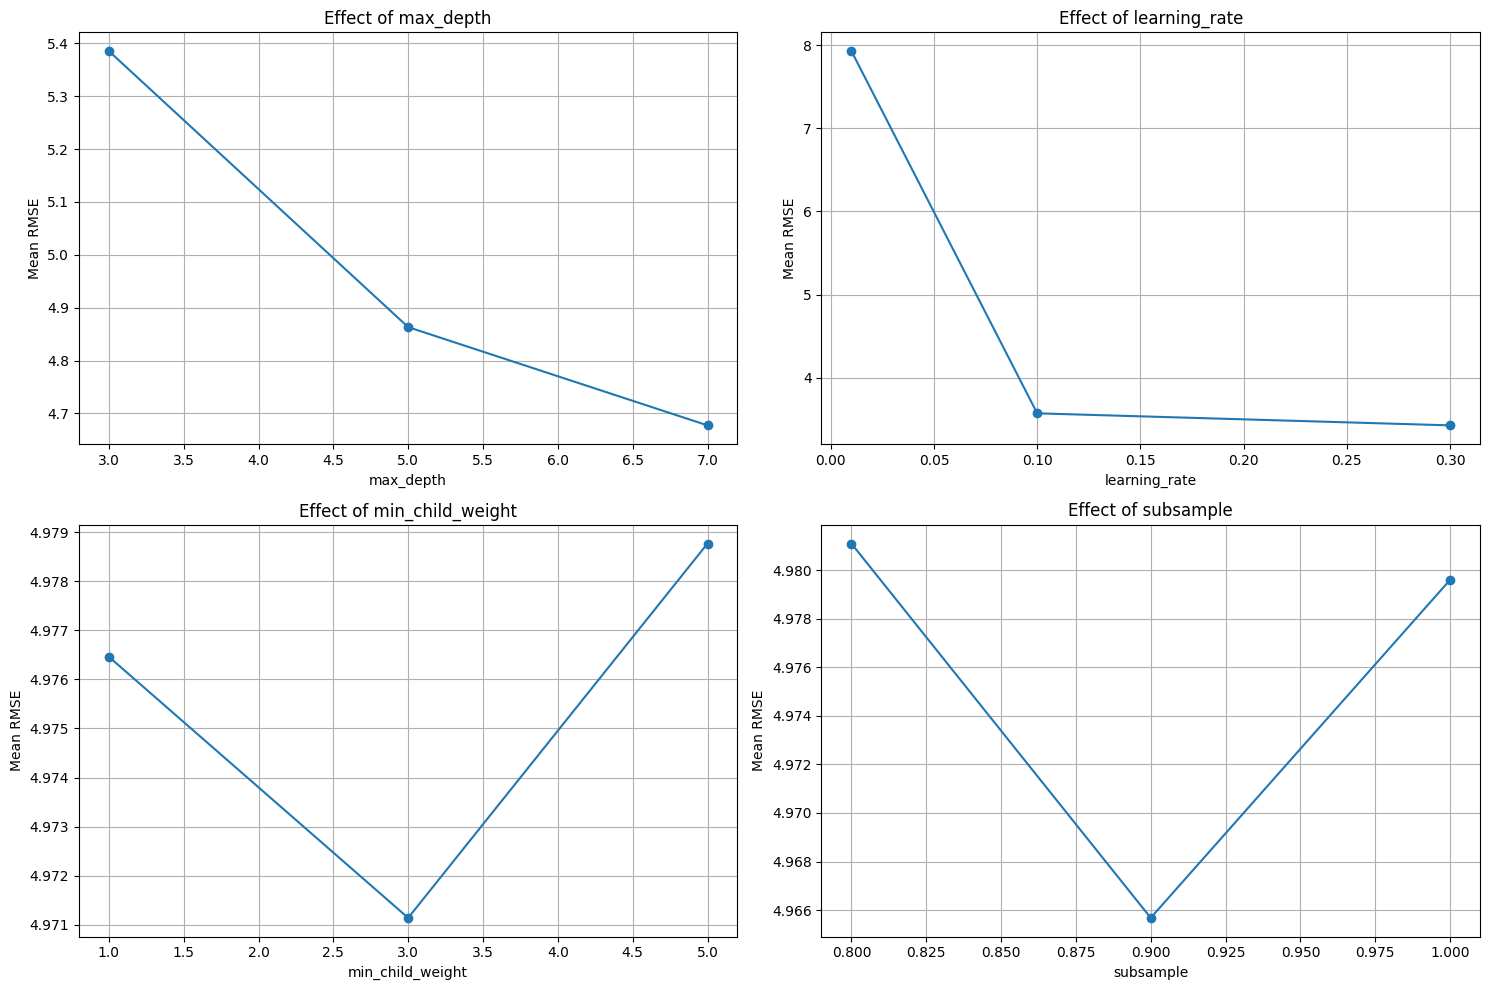


Model Performance Metrics:
- Training RMSE: 1.8328
- Testing RMSE: 3.4951
- Training MAE: 1.4008
- Testing MAE: 2.3801
- Training R²: 0.9877
- Testing R²: 0.9568


In [26]:
# Tune the model and get the best parameters
best_xgb_model, results_df, best_params_complete = tune_xgboost_manual(X_train, y_train)

# Evaluate the best model
train_rmse, test_rmse = evaluate_xgboost_model(
    best_xgb_model, X_train, X_test, y_train, y_test)


### Step 9: Predict on unseen data (final test set) based on the **best XGBoost model**

In [27]:
# Convert final test data to DMatrix
dfinal = xgb.DMatrix(X_final_test)

# Make predictions on final test set
y_pred_final = best_xgb_model.predict(dfinal)

# Calculate metrics
rmse_final = np.sqrt(mean_squared_error(y_final_test, y_pred_final))
mae_final = mean_absolute_error(y_final_test, y_pred_final)
r2_final = r2_score(y_final_test, y_pred_final)

print("\nFinal Test Metrics:")
print(f"- RMSE: {rmse_final:.4f}")
print(f"- MAE: {mae_final:.4f}")
print(f"- R-squared: {r2_final:.4f}")


Final Test Metrics:
- RMSE: 3.0847
- MAE: 2.1363
- R-squared: 0.9641


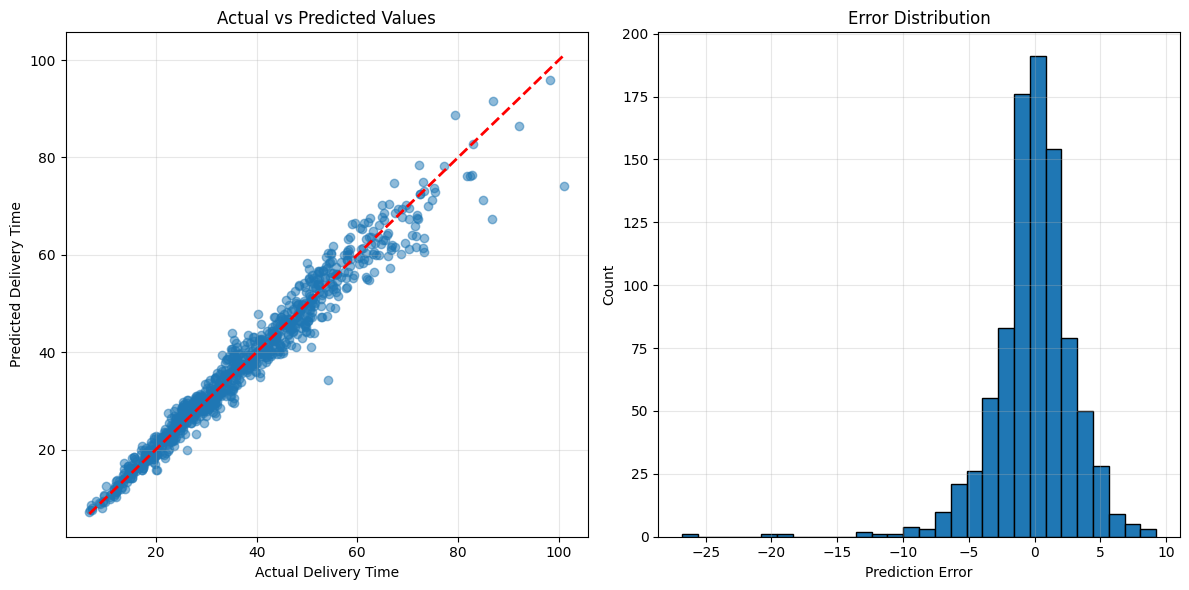

In [28]:
# Create comparison plot
plt.figure(figsize=(12, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_final_test, y_pred_final, alpha=0.5)
plt.plot([y_final_test.min(), y_final_test.max()], 
            [y_final_test.min(), y_final_test.max()], 
            'r--', lw=2)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Values')
plt.grid(True, alpha=0.3)

# Error distribution
plt.subplot(1, 2, 2)
errors = y_pred_final - y_final_test
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Error Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Create detailed comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': y_final_test,
    'Predicted': y_pred_final,
    'Error': errors,
    'AbsoluteError': np.abs(errors)
})

comparison_df.head()

,Actual,Predicted,Error,AbsoluteError
8600,60.3,58.190815,-2.109185,2.109185
2137,19.3,19.709032,0.409032,0.409032
874,75.4,73.001213,-2.398787,2.398787
6844,29.0,28.343863,-0.656137,0.656137
3095,40.5,40.508038,0.008038,0.008038


In [30]:
# Error Statistics of comparison_df
print("\nError Statistics:")
print(comparison_df['Error'].describe())


Error Statistics:
count    904.000000
mean      -0.106014
std        3.084618
min      -26.804153
25%       -1.442193
50%        0.005618
75%        1.605360
max        9.250131
Name: Error, dtype: float64


In [31]:
# Identify worst predictions
print("\nWorst 10 Predictions:")
worst_predictions = comparison_df.nlargest(10, 'AbsoluteError')
worst_predictions


Worst 10 Predictions:


,Actual,Predicted,Error,AbsoluteError
22,101.0,74.195847,-26.804153,26.804153
911,54.1,34.272648,-19.827352,19.827352
393,86.8,67.431595,-19.368405,19.368405
7225,84.9,71.360680,-13.539320,13.539320
1328,73.2,60.630272,-12.569728,12.569728
7356,73.0,61.315292,-11.684708,11.684708
6235,71.6,61.551971,-10.048029,10.048029
9358,50.8,41.021782,-9.778218,9.778218
5910,73.2,63.554203,-9.645797,9.645797
8933,79.4,88.650131,9.250131,9.250131


In [32]:
# Identify best predictions
print("\nBest 10 Predictions:")
best_predictions = comparison_df.nsmallest(10, 'AbsoluteError')
best_predictions


Best 10 Predictions:


,Actual,Predicted,Error,AbsoluteError
421,12.5,12.498959,-0.001041,0.001041
5153,39.7,39.698116,-0.001884,0.001884
9166,9.5,9.497369,-0.002631,0.002631
5705,40.1,40.103199,0.003199,0.003199
1921,15.5,15.493390,-0.006610,0.006610
1482,46.2,46.192223,-0.007777,0.007777
3095,40.5,40.508038,0.008038,0.008038
3328,23.8,23.783335,-0.016665,0.016665
8106,51.2,51.219090,0.019090,0.019090
6164,29.8,29.777843,-0.022157,0.022157


### Step 10: Save the model

In [33]:
xgb_model.save_model('xgb_model_v3.json')  # Saves the model in JSON format
xgb_model.save_model('xgb_model_v3.bin')  # Saves the model in binary format


/opt/anaconda3/envs/mis636-pybiz/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:09:54] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


### Step 11: Predict on hand data

In [34]:
# First, create the data without the ID fields since we drop those
hand_prediction_data = {
    "Delivery_person_Age": 32.0,
    "Delivery_person_Ratings": 4.6,
    "Restaurant_latitude": 12.972793,
    "Restaurant_longitude": 80.249982,
    "Delivery_location_latitude": 13.012793,
    "Delivery_location_longitude": 80.289982,
    "Type_of_order": 'Snack',
    "Type_of_vehicle": 'Scooter',
    "temperature": 26.55,
    "humidity": 87.0,
    "precipitation": 0.0,
    "weather_description": 'Mist',
    "Traffic_Level": 'High',
    "Distance (km)": 9.89
}

# Convert to DataFrame
hand_prediction_df = pd.DataFrame([hand_prediction_data])

# Ensure correct data types for numeric columns
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
                'Restaurant_latitude', 'Restaurant_longitude',
                'Delivery_location_latitude', 'Delivery_location_longitude',
                'temperature', 'humidity', 'precipitation', 'Distance (km)']

# Convert to numeric
for col in numeric_cols:
    hand_prediction_df[col] = pd.to_numeric(hand_prediction_df[col])

# Encode categorical variables using the same encoders from training
categorical_columns = ['Type_of_order', 'Type_of_vehicle', 'weather_description', 'Traffic_Level']

# Using the encoders dictionary from your training process
for col in categorical_columns:
    hand_prediction_df[col] = encoders[col].transform(hand_prediction_df[col])

# Convert to DMatrix
dpred_hand = xgb.DMatrix(hand_prediction_df)

# Make prediction
prediction = best_xgb_model.predict(dpred_hand)
print(f"Predicted delivery time: {prediction[0]:.2f} minutes")

Predicted delivery time: 40.62 minutes


### Step 11: Plot learning curves (tuned/best models)

Plot training test deviance for tuned/best model


Best parameters for model:
- objective: reg:squarederror
- eval_metric: rmse
- random_state: 13
- max_depth: 7
- learning_rate: 0.1
- min_child_weight: 1
- subsample: 0.9


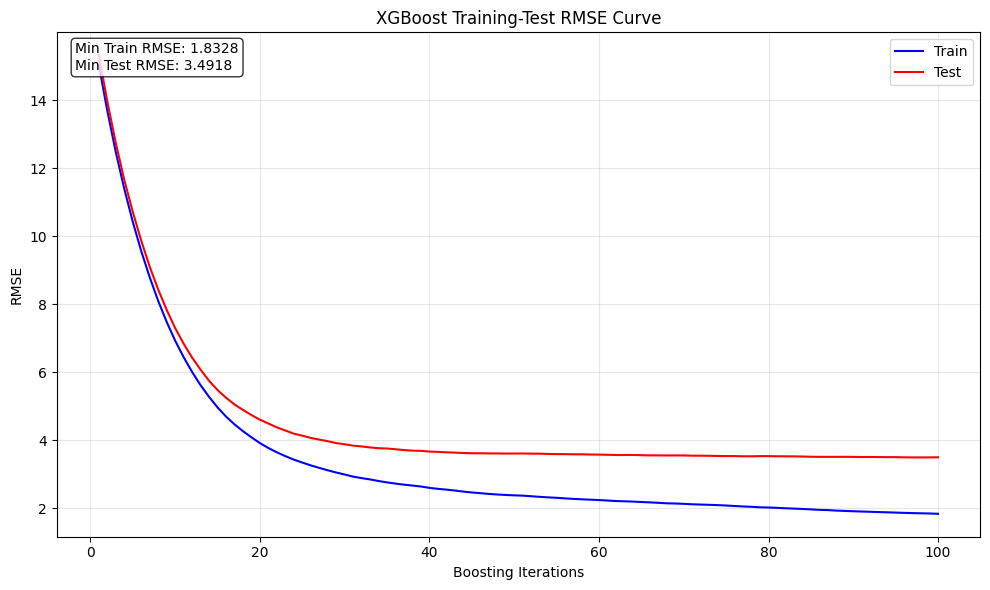

In [35]:
# Prepare data in DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up evaluation list
eval_list = [(dtrain, 'train'), (dtest, 'test')]

# Dictionary to store evaluation results
evals_result = {}

# Get the best parameters with base parameters included
best_idx = results_df['mean_rmse'].argmin()
best_tuned_params = results_df.iloc[best_idx]['params']

# Create params_best using the tuned values
params_best = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 13,
    'max_depth': best_tuned_params['max_depth'],
    'learning_rate': best_tuned_params['learning_rate'],
    'min_child_weight': best_tuned_params['min_child_weight'],
    'subsample': best_tuned_params['subsample']
}

print("\nBest parameters for model:")
for param, value in params_best.items():
    print(f"- {param}: {value}")

num_rounds = 100  # or whatever number of rounds your best model used

model = xgb.train(
    params_best,
    dtrain,
    num_rounds,
    evals=eval_list,
    evals_result=evals_result,
    verbose_eval=False
)

# Plot the training-test curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(evals_result['train']['rmse']) + 1), 
         evals_result['train']['rmse'], 
         'b-', 
         label='Train')
plt.plot(range(1, len(evals_result['test']['rmse']) + 1), 
         evals_result['test']['rmse'], 
         'r-', 
         label='Test')

# Customize the plot
plt.title('XGBoost Training-Test RMSE Curve')
plt.xlabel('Boosting Iterations')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Add min values as text
min_train_rmse = min(evals_result['train']['rmse'])
min_test_rmse = min(evals_result['test']['rmse'])
plt.text(0.02, 0.98, f'Min Train RMSE: {min_train_rmse:.4f}\nMin Test RMSE: {min_test_rmse:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Visualize tree for tuned/best model

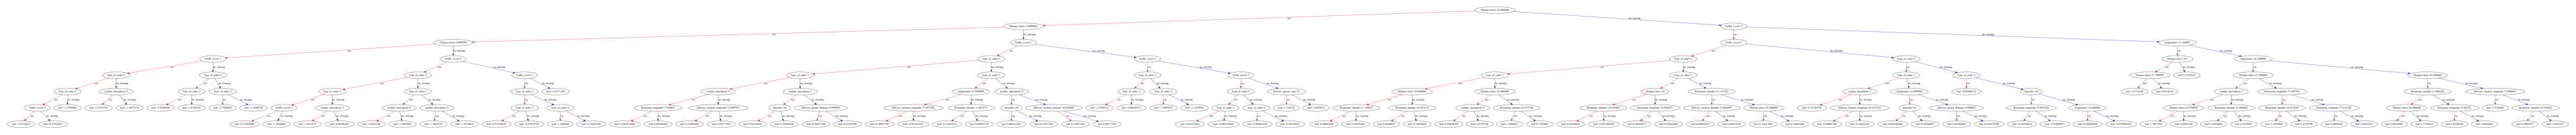

In [36]:
plt.rcParams['figure.figsize'] = (50, 25)
xgb.plot_tree(best_xgb_model, num_trees=0)
plt.show()

### References

- https://www.kaggle.com/datasets/gautamdeora7/food-delivery-time-a-multi-factor-dataset/data
- https://colab.research.google.com/github/kirenz/regression/blob/main/docs/xgboost-regression.ipynb#scrollTo=U-tDjPhi7OBQ
- https://randomrealizations.com/posts/xgboost-for-regression-in-python/
- https://github.com/dmlc/xgboost/issues/6909
- https://towardsdatascience.com/xgboost-intro-step-by-step-implementation-and-performance-comparison-6018dfa212f3
- https://github.com/Genpeng/xgboost-examples/tree/master?tab=readme-ov-file
- https://pygraphviz.github.io/documentation/stable/install.html
    - `conda install python-graphviz`